In [10]:
# Cell 1: Import & Environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import os
import warnings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [11]:
# Cell 2: Functions
def calculate_directional_accuracy(y_actual, y_pred):
    """Calculates the percentage of times the model correctly predicted Up or Down."""
    # Convert absolute values to directional changes (difference from yesterday)
    actual_diff = np.diff(y_actual)
    pred_diff = np.diff(y_pred)
    
    # 1 if up/flat, 0 if down
    actual_dir = np.where(actual_diff >= 0, 1, 0)
    pred_dir = np.where(pred_diff >= 0, 1, 0)
    
    # Hit Ratio
    accuracy = np.mean(actual_dir == pred_dir) * 100
    return accuracy

def calculate_all_metrics(y_actual, y_pred):
    """Returns a dictionary containing all key methodology metrics."""
    return {
        "R2": r2_score(y_actual, y_pred),
        "MAE": mean_absolute_error(y_actual, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_actual, y_pred)),
        "MSE": mean_squared_error(y_actual, y_pred),
        "MAPE": mean_absolute_percentage_error(y_actual, y_pred) * 100, # In percentage
        "Dir_Acc": calculate_directional_accuracy(y_actual, y_pred)
    }

In [12]:
# Cell 3: Model Architecture Definitions
# 1. Standard LSTM (Used for Prices-LSTM and Prices-News-LSTM)
class StockPredictorLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1, dropout_rate=0.2):
        super(StockPredictorLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout_rate if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc2(self.relu(self.fc1(self.dropout(lstm_out[:, -1, :]))))
        return out

# 2. BiLSTM without Attention
class StockPredictorBiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1, dropout_rate=0.2):
        super(StockPredictorBiLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
                            batch_first=True, bidirectional=True, dropout=dropout_rate)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_size * 2, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc2(self.relu(self.fc1(self.dropout(lstm_out[:, -1, :]))))
        return out

# 3. BiLSTM with Attention
class StockPredictorBiLSTMAttention(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1, dropout_rate=0.2):
        super(StockPredictorBiLSTMAttention, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
                            batch_first=True, bidirectional=True, dropout=dropout_rate if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout_rate)
        self.attention = nn.Linear(hidden_size * 2, 1) 
        self.fc1 = nn.Linear(hidden_size * 2, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context_vector = torch.sum(attn_weights * lstm_out, dim=1)
        out = self.fc2(self.relu(self.fc1(self.dropout(context_vector))))
        return out

def create_sequences(df_ticker, seq_length, feature_cols):
    X, y = [], []
    for i in range(len(df_ticker) - seq_length):
        X.append(df_ticker[feature_cols].iloc[i : i + seq_length].values)
        y.append(df_ticker['Close'].iloc[i + seq_length])
    return np.array(X), np.array(y)

In [ ]:
# Cell 4: Inference loop
tickers = ['MSFT', 'DIS', 'WMT']
models = ['Prices-LSTM', 'Prices-News-LSTM', 'Prices-News-BiLSTM', 'Prices-News-BiLSTM-Attention']
seq_lengths = [5, 10, 20]
NUM_RUNS = 10
all_results = []

for ticker in tickers:
    # 1. Load Data
    ticker_df = pd.read_csv(f"datasets/{ticker}/{ticker}_DatasetV1.csv")
    ticker_df['Trading_Date'] = pd.to_datetime(ticker_df['Trading_Date'])
    
    train_raw = ticker_df[ticker_df['Trading_Date'].dt.year <= 2022].copy()
    test_raw = ticker_df[ticker_df['Trading_Date'].dt.year == 2023].copy()
    
    for seq in seq_lengths:
        for model_name in models:
            
            # Feature routing mapping
            if model_name == 'Prices-LSTM':
                feature_cols = ['Close', 'Volume', 'SMA_20', 'RSI_14']
                pytorch_model_class = StockPredictorLSTM
                model_params = {'input_size': 4, 'hidden_size': 256, 'num_layers': 1}
                weight_dir = f"models/v1_PriceOnly/{ticker}"
                weight_prefix = "v1PriceOnly_run"
            elif model_name == 'Prices-News-LSTM':
                feature_cols = ['Close', 'Volume', 'Sentiment', 'SMA_20', 'RSI_14']
                pytorch_model_class = StockPredictorLSTM
                model_params = {'input_size': 5, 'hidden_size': 256, 'num_layers': 1}
                weight_dir = f"models/v1/{ticker}"
                weight_prefix = "v1_run"
            elif model_name == 'Prices-News-BiLSTM':
                feature_cols = ['Close', 'Volume', 'Sentiment', 'SMA_20', 'RSI_14']
                pytorch_model_class = StockPredictorBiLSTM
                model_params = {'input_size': 5, 'hidden_size': 128, 'num_layers': 2}
                weight_dir = f"models/v2_no_attention/{ticker}"
                weight_prefix = "v2_no_att_run"
            elif model_name == 'Prices-News-BiLSTM-Attention':
                feature_cols = ['Close', 'Volume', 'Sentiment', 'SMA_20', 'RSI_14']
                pytorch_model_class = StockPredictorBiLSTMAttention
                model_params = {'input_size': 5, 'hidden_size': 128, 'num_layers': 2}
                weight_dir = f"models/v2_attention/{ticker}"
                weight_prefix = "v2_att_run"

            # 2. Dynamic Scaling based on the features the model needs
            scaler = MinMaxScaler()
            train_copy = train_raw.copy()
            test_copy = test_raw.copy()
            train_copy[feature_cols] = scaler.fit_transform(train_copy[feature_cols])
            test_copy[feature_cols] = scaler.transform(test_copy[feature_cols])

            # 3. Create Sequence & Tensors
            X_test, y_test = create_sequences(test_copy, seq, feature_cols)
            X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
            
            for run in range(1, NUM_RUNS + 1):
                weight_file = f"{weight_dir}/{weight_prefix}_{run}_seq{seq}.pth"
                if not os.path.exists(weight_file):
                    continue

                # 4. Load Pre-trained weights
                model = pytorch_model_class(**model_params).to(device)
                model.load_state_dict(torch.load(weight_file, map_location=device, weights_only=True))
                model.eval()

                with torch.no_grad():
                    y_pred = model(X_test_t).cpu().numpy().flatten()
                
                # Calculate metrics
                metrics = calculate_all_metrics(y_test, y_pred)
                all_results.append({
                    "Ticker": ticker,
                    "Model": model_name,
                    "Seq": seq,
                    "Run": run,
                    **metrics
                })

    df_master = pd.DataFrame(all_results)
    # State which columns we are calculating
    metrics_cols = ['R2', 'MAE', 'RMSE', 'MSE', 'MAPE', 'Dir_Acc']
    # Group by our configurations and calculate mean/std
    summary_df = df_master.groupby(['Ticker', 'Model', 'Seq'])[metrics_cols].agg(['mean', 'std'])
    # Create a new empty dataframe for our beautifully formatted strings
    formatted_df = pd.DataFrame(index=summary_df.index)
    # Loop through each metric and merge the mean and std with "±"
    for col in metrics_cols:
        means = summary_df[(col, 'mean')].map('{:.3f}'.format)
        stds = summary_df[(col, 'std')].map('{:.3f}'.format)
        formatted_df[col] = means + " ± " + stds
    # Export to CSV!
    formatted_df.to_csv("Master_Methodology_Metrics.csv", encoding='utf-8-sig')
    print("\n" + "="*50)
    print("INFERENCE COMPLETE. Formatted data saved to Master_Methodology_Metrics.csv")
    display(formatted_df)


INFERENCE COMPLETE. Formatted data saved to Master_Methodology_Metrics.csv


R2            MAE  \
Ticker Model                        Seq                                 
MSFT   Prices-LSTM                  5    0.966 ± 0.021  0.023 ± 0.008   
                                    10   0.959 ± 0.019  0.026 ± 0.007   
                                    20   0.930 ± 0.041  0.031 ± 0.011   
       Prices-News-BiLSTM           5    0.968 ± 0.012  0.023 ± 0.005   
                                    10   0.973 ± 0.008  0.020 ± 0.003   
                                    20   0.969 ± 0.012  0.020 ± 0.004   
       Prices-News-BiLSTM-Attention 5    0.967 ± 0.012  0.023 ± 0.004   
                                    10   0.959 ± 0.031  0.025 ± 0.009   
                                    20   0.940 ± 0.033  0.028 ± 0.009   
       Prices-News-LSTM             5    0.967 ± 0.013  0.023 ± 0.005   
                                    10   0.958 ± 0.013  0.026 ± 0.005   
                                    20   0.961 ± 0.018  0.022 ± 0.006   

                                                  RMSE            MSE  \
Ticker Model                        Seq                                 
MSFT   Prices-LSTM                  5    0.028 ± 0.009  0.001 ± 0.001   
                                    10   0.031 ± 0.007  0.001 ± 0.000   
                                    20   0.037 ± 0.011  0.001 ± 0.001   
       Prices-News-BiLSTM           5    0.028 ± 0.005  0.001 ± 0.000   
                                    10   0.025 ± 0.004  0.001 ± 0.000   
                                    20   0.025 ± 0.005  0.001 ± 0.000   
       Prices-News-BiLSTM-Attention 5    0.029 ± 0.005  0.001 ± 0.000   
                                    10   0.030 ± 0.010  0.001 ± 0.001   
                                    20   0.034 ± 0.009  0.001 ± 0.001   
       Prices-News-LSTM             5    0.029 ± 0.005  0.001 ± 0.000   
                                    10   0.031 ± 0.005  0.001 ± 0.000   
                                    20   0.028 ± 0.006  0.001 ± 0.000   

                                                  MAPE         Dir_Acc  
Ticker Model                        Seq                                 
MSFT   Prices-LSTM                  5    2.644 ± 0.867  45.314 ± 0.560  
                                    10   2.847 ± 0.676  46.026 ± 0.728  
                                    20   3.357 ± 1.110  45.580 ± 0.879  
       Prices-News-BiLSTM           5    2.536 ± 0.514  53.347 ± 0.843  
                                    10   2.212 ± 0.359  52.735 ± 1.107  
                                    20   2.185 ± 0.456  52.634 ± 0.444  
       Prices-News-BiLSTM-Attention 5    2.555 ± 0.449  52.427 ± 1.528  
                                    10   2.810 ± 0.970  52.863 ± 0.856  
                                    20   3.083 ± 0.877  51.384 ± 2.171  
       Prices-News-LSTM             5    2.618 ± 0.530  51.674 ± 1.745  
                                    10   2.856 ± 0.490  51.026 ± 1.309  
                                    20   2.466 ± 0.581  49.107 ± 1.847


INFERENCE COMPLETE. Formatted data saved to Master_Methodology_Metrics.csv


R2            MAE  \
Ticker Model                        Seq                                 
DIS    Prices-LSTM                  5    0.894 ± 0.033  0.017 ± 0.003   
                                    10   0.888 ± 0.026  0.018 ± 0.002   
                                    20   0.866 ± 0.047  0.019 ± 0.004   
       Prices-News-BiLSTM           5    0.902 ± 0.045  0.016 ± 0.004   
                                    10   0.859 ± 0.055  0.021 ± 0.005   
                                    20   0.860 ± 0.040  0.019 ± 0.003   
       Prices-News-BiLSTM-Attention 5    0.887 ± 0.029  0.018 ± 0.003   
                                    10   0.911 ± 0.016  0.016 ± 0.001   
                                    20   0.874 ± 0.034  0.018 ± 0.002   
       Prices-News-LSTM             5    0.886 ± 0.043  0.018 ± 0.004   
                                    10   0.874 ± 0.039  0.019 ± 0.003   
                                    20   0.891 ± 0.033  0.017 ± 0.003   
MSFT   Prices-LSTM                  5    0.966 ± 0.021  0.023 ± 0.008   
                                    10   0.959 ± 0.019  0.026 ± 0.007   
                                    20   0.930 ± 0.041  0.031 ± 0.011   
       Prices-News-BiLSTM           5    0.968 ± 0.012  0.023 ± 0.005   
                                    10   0.973 ± 0.008  0.020 ± 0.003   
                                    20   0.969 ± 0.012  0.020 ± 0.004   
       Prices-News-BiLSTM-Attention 5    0.967 ± 0.012  0.023 ± 0.004   
                                    10   0.959 ± 0.031  0.025 ± 0.009   
                                    20   0.940 ± 0.033  0.028 ± 0.009   
       Prices-News-LSTM             5    0.967 ± 0.013  0.023 ± 0.005   
                                    10   0.958 ± 0.013  0.026 ± 0.005   
                                    20   0.961 ± 0.018  0.022 ± 0.006   

                                                  RMSE            MSE  \
Ticker Model                        Seq                                 
DIS    Prices-LSTM                  5    0.022 ± 0.003  0.000 ± 0.000   
                                    10   0.022 ± 0.003  0.001 ± 0.000   
                                    20   0.023 ± 0.004  0.001 ± 0.000   
       Prices-News-BiLSTM           5    0.021 ± 0.005  0.000 ± 0.000   
                                    10   0.025 ± 0.005  0.001 ± 0.000   
                                    20   0.024 ± 0.004  0.001 ± 0.000   
       Prices-News-BiLSTM-Attention 5    0.022 ± 0.003  0.001 ± 0.000   
                                    10   0.020 ± 0.002  0.000 ± 0.000   
                                    20   0.023 ± 0.003  0.001 ± 0.000   
       Prices-News-LSTM             5    0.022 ± 0.004  0.001 ± 0.000   
                                    10   0.024 ± 0.003  0.001 ± 0.000   
                                    20   0.021 ± 0.003  0.000 ± 0.000   
MSFT   Prices-LSTM                  5    0.028 ± 0.009  0.001 ± 0.001   
                                    10   0.031 ± 0.007  0.001 ± 0.000   
                                    20   0.037 ± 0.011  0.001 ± 0.001   
       Prices-News-BiLSTM           5    0.028 ± 0.005  0.001 ± 0.000   
                                    10   0.025 ± 0.004  0.001 ± 0.000   
                                    20   0.025 ± 0.005  0.001 ± 0.000   
       Prices-News-BiLSTM-Attention 5    0.029 ± 0.005  0.001 ± 0.000   
                                    10   0.030 ± 0.010  0.001 ± 0.001   
                                    20   0.034 ± 0.009  0.001 ± 0.001   
       Prices-News-LSTM             5    0.029 ± 0.005  0.001 ± 0.000   
                                    10   0.031 ± 0.005  0.001 ± 0.000   
                                    20   0.028 ± 0.006  0.001 ± 0.000   

                                                     MAPE         Dir_Acc  
Ticker Model                        Seq                                    
DIS    Prices-LSTM                  5    130.427 ± 48.796  48.996 ± 0.750  
                          


INFERENCE COMPLETE. Formatted data saved to Master_Methodology_Metrics.csv


R2            MAE  \
Ticker Model                        Seq                                 
DIS    Prices-LSTM                  5    0.894 ± 0.033  0.017 ± 0.003   
                                    10   0.888 ± 0.026  0.018 ± 0.002   
                                    20   0.866 ± 0.047  0.019 ± 0.004   
       Prices-News-BiLSTM           5    0.902 ± 0.045  0.016 ± 0.004   
                                    10   0.859 ± 0.055  0.021 ± 0.005   
                                    20   0.860 ± 0.040  0.019 ± 0.003   
       Prices-News-BiLSTM-Attention 5    0.887 ± 0.029  0.018 ± 0.003   
                                    10   0.911 ± 0.016  0.016 ± 0.001   
                                    20   0.874 ± 0.034  0.018 ± 0.002   
       Prices-News-LSTM             5    0.886 ± 0.043  0.018 ± 0.004   
                                    10   0.874 ± 0.039  0.019 ± 0.003   
                                    20   0.891 ± 0.033  0.017 ± 0.003   
MSFT   Prices-LSTM                  5    0.966 ± 0.021  0.023 ± 0.008   
                                    10   0.959 ± 0.019  0.026 ± 0.007   
                                    20   0.930 ± 0.041  0.031 ± 0.011   
       Prices-News-BiLSTM           5    0.968 ± 0.012  0.023 ± 0.005   
                                    10   0.973 ± 0.008  0.020 ± 0.003   
                                    20   0.969 ± 0.012  0.020 ± 0.004   
       Prices-News-BiLSTM-Attention 5    0.967 ± 0.012  0.023 ± 0.004   
                                    10   0.959 ± 0.031  0.025 ± 0.009   
                                    20   0.940 ± 0.033  0.028 ± 0.009   
       Prices-News-LSTM             5    0.967 ± 0.013  0.023 ± 0.005   
                                    10   0.958 ± 0.013  0.026 ± 0.005   
                                    20   0.961 ± 0.018  0.022 ± 0.006   
WMT    Prices-LSTM                  5    0.893 ± 0.055  0.030 ± 0.010   
                                    10   0.788 ± 0.075  0.045 ± 0.009   
                                    20   0.835 ± 0.108  0.036 ± 0.012   
       Prices-News-BiLSTM           5    0.911 ± 0.037  0.028 ± 0.007   
                                    10   0.891 ± 0.081  0.030 ± 0.012   
                                    20   0.901 ± 0.034  0.028 ± 0.006   
       Prices-News-BiLSTM-Attention 5    0.908 ± 0.040  0.028 ± 0.008   
                                    10   0.897 ± 0.052  0.030 ± 0.009   
                                    20   0.891 ± 0.053  0.030 ± 0.009   
       Prices-News-LSTM             5    0.909 ± 0.039  0.028 ± 0.007   
                                    10   0.885 ± 0.044  0.032 ± 0.007   
                                    20   0.761 ± 0.144  0.044 ± 0.015   

                                                  RMSE            MSE  \
Ticker Model                        Seq                                 
DIS    Prices-LSTM                  5    0.022 ± 0.003  0.000 ± 0.000   
                                    10   0.022 ± 0.003  0.001 ± 0.000   
                                    20   0.023 ± 0.004  0.001 ± 0.000   
       Prices-News-BiLSTM           5    0.021 ± 0.005  0.000 ± 0.000   
                                    10   0.025 ± 0.005  0.001 ± 0.000   
                                    20   0.024 ± 0.004  0.001 ± 0.000   
       Prices-News-BiLSTM-Attention 5    0.022 ± 0.003  0.001 ± 0.000   
                                    10   0.020 ± 0.002  0.000 ± 0.000   
                                    20   0.023 ± 0.003  0.001 ± 0.000   
       Prices-News-LSTM             5    0.022 ± 0.004  0.001 ± 0.000   
                                    10   0.024 ± 0.003  0.001 ± 0.000   
                                    20   0.021 ± 0.003  0.000 ± 0.000   
MSFT   Prices-LSTM                  5    0.028 ± 0.009  0.001 ± 0.001   
                                    10   0.031 ± 0.007  0.001 ± 0.000   
                                    20   0.037 ± 0.011  0.001 ± 0.001   
       Prices-News-BiLSTM           

> Median R2 across 10 runs: 0.9547
> Statistically representative model found: Loading Run 10...


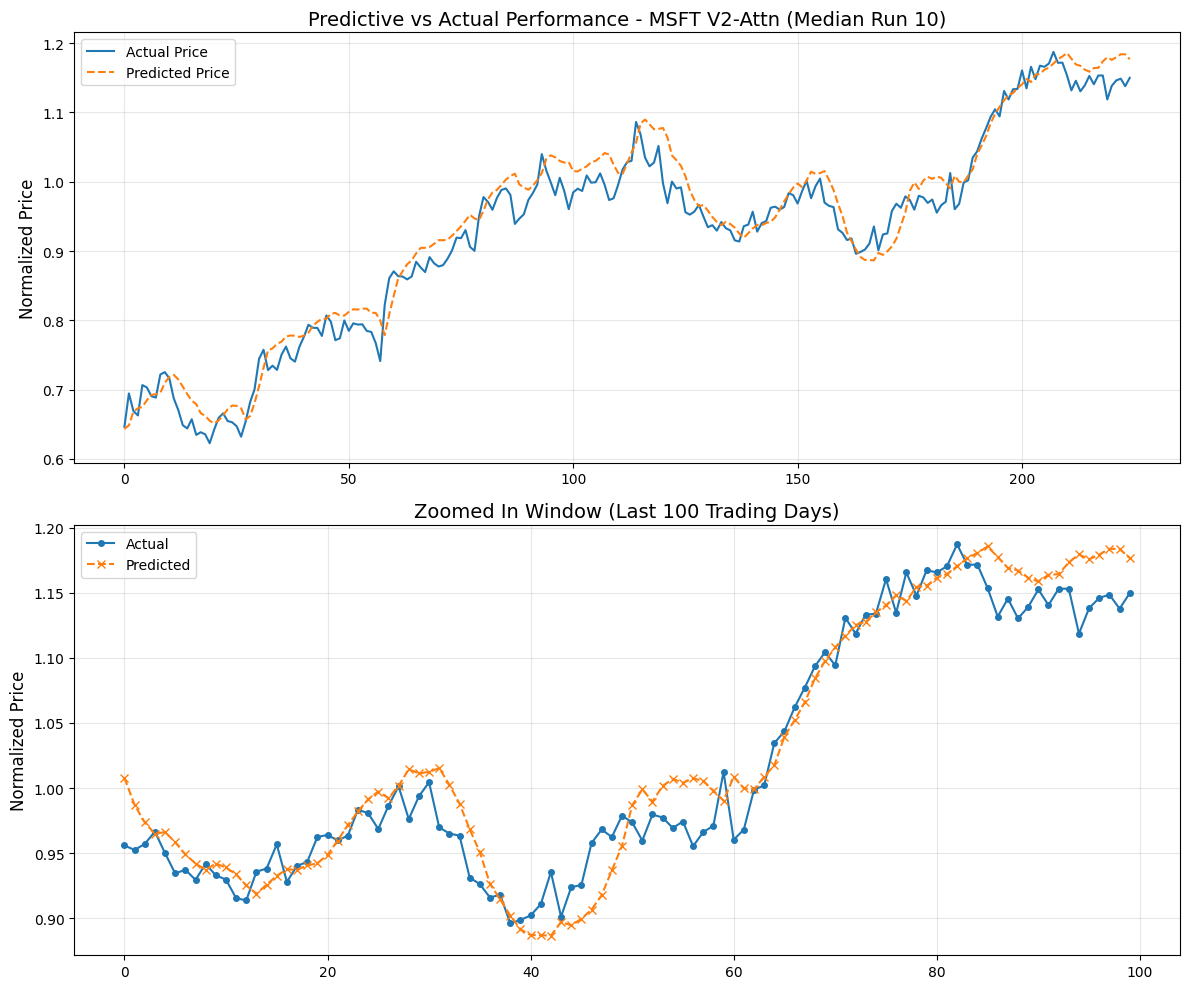

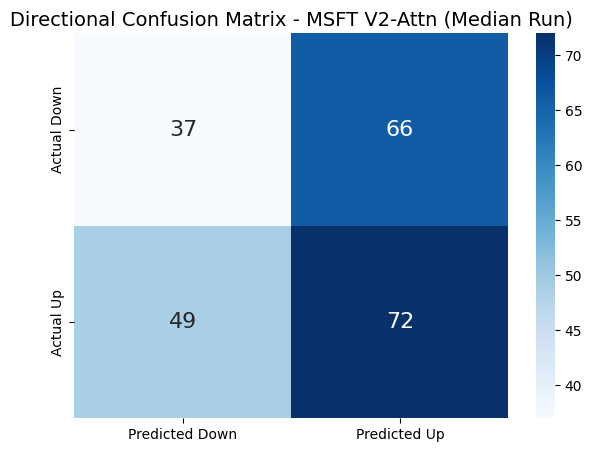

In [14]:
# Cell 5: Median Model Visualization
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler

ticker = 'MSFT'
seq = 20

# 1. Dynamically find the Median Model from your saved results!
csv_path = f"results/trainV2_attention/v2_att_stability_results_{seq}.csv"
df_res = pd.read_csv(csv_path)

# Filter for MSFT and Sequence 20
df_msft = df_res[(df_res['Ticker'] == ticker) & (df_res['Seq'] == seq)].copy()

# Calculate median R2
median_r2 = df_msft['R2'].median()

# Find the specific run closest to the median
df_msft['Dist_from_Median'] = abs(df_msft['R2'] - median_r2)
median_row = df_msft.loc[df_msft['Dist_from_Median'].idxmin()]
median_run = int(median_row['Run'])

print(f"> Median R2 across 10 runs: {median_r2:.4f}")
print(f"> Statistically representative model found: Loading Run {median_run}...")

weight_file = f"models/v2_attention/{ticker}/v2_att_run_{median_run}_seq{seq}.pth"

# 2. Load the Test Data
ticker_df = pd.read_csv(f"datasets/{ticker}/{ticker}_DatasetV1.csv")
ticker_df['Trading_Date'] = pd.to_datetime(ticker_df['Trading_Date'])
test_raw = ticker_df[ticker_df['Trading_Date'].dt.year == 2023].copy()
train_raw = ticker_df[ticker_df['Trading_Date'].dt.year <= 2022].copy()

scaler = MinMaxScaler()
cols = ['Close', 'Volume', 'Sentiment', 'SMA_20', 'RSI_14']
scaler.fit(train_raw[cols])
test_scaled = test_raw.copy()
test_scaled[cols] = scaler.transform(test_scaled[cols])

X_test, y_test = create_sequences(test_scaled, seq, cols)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

# 3. Get the Predictions using the Median weights!
model = StockPredictorBiLSTMAttention(input_size=5, hidden_size=128, num_layers=2).to(device)
model.load_state_dict(torch.load(weight_file, map_location=device, weights_only=True))
model.eval()

with torch.no_grad():
    y_pred = model(X_test_t).cpu().numpy().flatten()

# Graph 1: Predict vs Actual
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Top: Full Year
ax1.plot(y_test, label='Actual Price', color='#1f77b4', linewidth=1.5)
ax1.plot(y_pred, label='Predicted Price', color='#ff7f0e', linestyle='--', linewidth=1.5)
ax1.set_title(f"Predictive vs Actual Performance - {ticker} V2-Attn (Median Run {median_run})", fontsize=14)
ax1.set_ylabel("Normalized Price", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom: Zoomed 100 Days (Crucial to prove no lagging!)
zoom = 100
ax2.plot(y_test[-zoom:], label='Actual', color='#1f77b4', marker='o', markersize=4)
ax2.plot(y_pred[-zoom:], label='Predicted', color='#ff7f0e', marker='x', linestyle='--')
ax2.set_title(f"Zoomed In Window (Last {zoom} Trading Days)", fontsize=14)
ax2.set_ylabel("Normalized Price", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Graph 2: Directional Confusion
actual_diff = np.diff(y_test)
pred_diff = np.diff(y_pred)
actual_dir = np.where(actual_diff >= 0, 1, 0)
pred_dir = np.where(pred_diff >= 0, 1, 0)

cm = confusion_matrix(actual_dir, pred_dir)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Down', 'Predicted Up'],
            yticklabels=['Actual Down', 'Actual Up'],
            annot_kws={"size": 16})
plt.title(f"Directional Confusion Matrix - {ticker} V2-Attn (Median Run)", fontsize=14)
plt.show()
